In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.8/906.8 kB 24.1 MB/s eta 0:00:00


In [2]:
# Create the YAML file content as a string
yaml_content = f"""
path: /kaggle/input/ktp-image-segmentation-v1 # dataset root dir
train: images/train
val: images/valid
test: images/test

names:
    0: ktp
"""

# Write the YAML content to a file
with open('data.yaml', 'w') as f:
  f.write(yaml_content)

print(f"Successfully created data.yaml")

Successfully created data.yaml


In [3]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n-seg.pt")  # load a pretrained model

# Train the model
results = model.train(data="data.yaml", epochs=100, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.90M/5.90M [00:00<00:00, 104MB/s]


Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line

100%|██████████| 755k/755k [00:00<00:00, 25.4MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

...

    100/100      2.94G    0.08132     0.1013    0.06653     0.8538          7        640: 100%|██████████| 351/351 [01:23<00:00,  4.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:04<00:00,  3.64it/s]

                   all        535        542      0.996      0.998      0.993      0.993      0.996      0.998      0.993      0.993



100 epochs completed in 2.533 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.0MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.0MB

Validating runs/segment/train/weights/best.pt...
Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,763 parameters, 0 gradients, 10.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:06<00:00,  2.61it/s]


                   all        535        542      0.996      0.997      0.995      0.994      0.996      0.997      0.995      0.993
Speed: 0.2ms preprocess, 3.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/segment/train


In [4]:
# Evaluate model on validation or test set
metrics = model.val(split='train')
print(metrics)

Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 265 layers, 2,834,763 parameters, 0 gradients, 10.2 GFLOPs


val: Scanning /kaggle/input/ktp-image-segmentation-v1/labels/train... 5607 images, 3 backgrounds, 0 corrupt: 100%|██████████| 5607/5607 [00:08<00:00, 646.18it/s]


val: WARNING ⚠️ Cache directory /kaggle/input/ktp-image-segmentation-v1/labels is not writeable, cache not saved.


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 351/351 [01:00<00:00,  5.78it/s]


                   all       5607       5691      0.999      0.997      0.995      0.992      0.999      0.997      0.995      0.993
Speed: 0.2ms preprocess, 5.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/segment/train2
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a10a2423d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,   

In [5]:
# Evaluate model on validation or test set
metrics = model.val(split='val')
print(metrics)

Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /kaggle/input/ktp-image-segmentation-v1/labels/valid... 535 images, 1 backgrounds, 0 corrupt: 100%|██████████| 535/535 [00:00<00:00, 610.34it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/ktp-image-segmentation-v1/labels is not writeable, cache not saved.



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 34/34 [00:07<00:00,  4.74it/s]


                   all        535        542      0.996      0.998      0.994      0.994      0.996      0.998      0.994      0.993
Speed: 0.3ms preprocess, 5.5ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/segment/train3
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a101ec00d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,   

In [6]:
# Evaluate model on validation or test set
metrics = model.val(split='test')
print(metrics)

Ultralytics 8.3.59 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15095MiB)


val: Scanning /kaggle/input/ktp-image-segmentation-v1/labels/test... 266 images, 0 backgrounds, 0 corrupt: 100%|██████████| 266/266 [00:01<00:00, 248.15it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/ktp-image-segmentation-v1/labels is not writeable, cache not saved.



/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:04<00:00,  3.67it/s]


                   all        266        267      0.999          1      0.995      0.991      0.999          1      0.995      0.993
Speed: 0.3ms preprocess, 5.8ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/segment/train4
ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a101ef6e680>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,   


image 1/1 /kaggle/input/ktp-image-segmentation-v1/images/test/100_jpg.rf.b692baacb3b5387d15da76f4b0068b82.jpg: 640x480 1 ktp, 60.4ms
Speed: 2.5ms preprocess, 60.4ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 480)


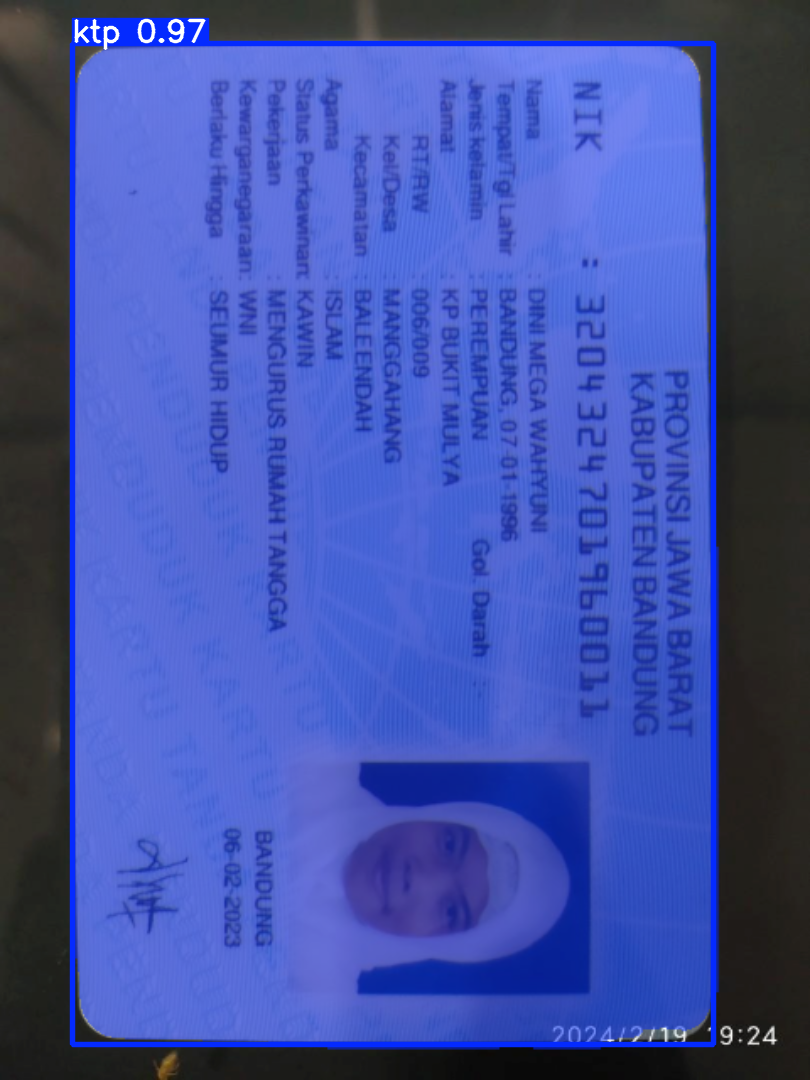

In [7]:
results = model("/kaggle/input/ktp-image-segmentation-v1/images/test/100_jpg.rf.b692baacb3b5387d15da76f4b0068b82.jpg")
results[0].show()